In [1]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "--force-reinstall", "--no-cache-dir",
    "torch==2.7.1",
    "torchvision==0.22.1",
    "torchaudio==2.7.1",
    "transformers==4.52.4",
    "accelerate==1.7.0",
    "datasets==3.6.0",
    "evaluate==0.4.3",
    "tokenizers==0.21.1"
])

0

In [1]:
import sys
import transformers
import accelerate
import datasets
import torch

print("Python executable:", sys.executable)
print("Transformers:", transformers.__version__, transformers.__file__)
print("Accelerate:", accelerate.__version__, accelerate.__file__)
print("Datasets:", datasets.__version__)
print("Torch:", torch.__version__)

Python executable: /usr/bin/python3
Transformers: 4.52.4 /usr/local/lib/python3.12/dist-packages/transformers/__init__.py
Accelerate: 1.7.0 /usr/local/lib/python3.12/dist-packages/accelerate/__init__.py
Datasets: 3.6.0
Torch: 2.7.1+cu126


In [2]:
# =========================================================
# 1. IMPORTS
# =========================================================
import os
import csv
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset
from sklearn.metrics import f1_score, classification_report
from scipy.stats import pearsonr

from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    RobertaModel,
    RobertaConfig,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    TrainerCallback,
    EarlyStoppingCallback
    
)

# =========================================================
# 2. GOOGLE DRIVE
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

os.makedirs("/content/drive/MyDrive", exist_ok=True)

LOG_FILE_STEP1 = "/content/drive/MyDrive/RoBERTa_Hierarchical_Step1.csv"
LOG_FILE_STEP2 = "/content/drive/MyDrive/RoBERTa_Hierarchical_Step2.csv"

for LOG_FILE, STEP_NAME in [
    (LOG_FILE_STEP1, "STEP 1"),
    (LOG_FILE_STEP2, "STEP 2")
]:
    with open(LOG_FILE, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)

      
        writer.writerow(["model", "roberta-base"])
        writer.writerow(["step", STEP_NAME])
        writer.writerow(["learning_rate", 2e-5])
        writer.writerow(["train_batch_size", 8,8])
        writer.writerow(["eval_batch_size", 8,8])
        writer.writerow(["epochs", 3,4])
        writer.writerow([])


# =========================================================
# 3. SEED + DEVICE
# =========================================================
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# 5. LOAD DATASET
# =========================================================
train_data = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="train")
val_data   = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="dev")
test_data  = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="test")

train_df = train_data.to_pandas()
val_df   = val_data.to_pandas()
test_df  = test_data.to_pandas()

print("Original sizes:")
print({
    "train": len(train_df),
    "val": len(val_df),
    "test": len(test_df)
})

# =========================================================
# 4. LABELS
# =========================================================
EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]
INTENSITY_COLUMNS = [f"{emotion}_intensity" for emotion in EMOTIONS]

LEVELS = [1, 2, 3]

LABELS = [
    f"{emotion}_{level}"
    for emotion in EMOTIONS
    for level in LEVELS
]


# =========================================================
# 6. PREPARE TWO-STEP DATA
# =========================================================
def prepare_two_step_data(df):
    df = df.copy()

    if "disgust" in df.columns:
        df = df.drop(columns=["disgust"])

    for emotion in EMOTIONS:
        df[f"{emotion}_intensity"] = df[emotion].astype(int)

    for emotion in EMOTIONS:
        df[emotion] = (df[f"{emotion}_intensity"] > 0).astype(int)

    return df

train_two = prepare_two_step_data(train_df)
val_two   = prepare_two_step_data(val_df)
test_two  = prepare_two_step_data(test_df)

# =========================================================
# 7. TRUE 70/20/10 SPLIT
# =========================================================
full_df = pd.concat([train_two, val_two, test_two], ignore_index=True)
full_df = full_df[["text"] + EMOTIONS + INTENSITY_COLUMNS]
full_df = full_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

n = len(full_df)
train_end = int(0.7 * n)
val_end = int(0.9 * n)

train_split = full_df[:train_end].reset_index(drop=True)
val_split   = full_df[train_end:val_end].reset_index(drop=True)
test_split  = full_df[val_end:].reset_index(drop=True)

print("New split sizes:")
print({
    "train": len(train_split),
    "val": len(val_split),
    "test": len(test_split)
})

print("\nSample data:")
print(train_df.head())

# =========================================================
# 8. STEP 1 DATA (EMOTION PRESENCE)
# =========================================================
train_step1_df = train_split[["text"] + EMOTIONS].copy()
val_step1_df   = val_split[["text"] + EMOTIONS].copy()
test_step1_df  = test_split[["text"] + EMOTIONS].copy()

# =========================================================
# 9. STEP 2 DATA (INTENSITY PREDICTION)
# =========================================================
train_step2_df = train_split[["text"] + INTENSITY_COLUMNS].copy()
val_step2_df   = val_split[["text"] + INTENSITY_COLUMNS].copy()
test_step2_df  = test_split[["text"] + INTENSITY_COLUMNS].copy()

# =========================================================
# 10. CONVERT TO HF DATASETS
# =========================================================
train_step1_ds = Dataset.from_pandas(train_step1_df, preserve_index=False)
val_step1_ds   = Dataset.from_pandas(val_step1_df, preserve_index=False)
test_step1_ds  = Dataset.from_pandas(test_step1_df, preserve_index=False)

train_step2_ds = Dataset.from_pandas(train_step2_df, preserve_index=False)
val_step2_ds   = Dataset.from_pandas(val_step2_df, preserve_index=False)
test_step2_ds  = Dataset.from_pandas(test_step2_df, preserve_index=False)

# =========================================================
# 11. TOKENIZER
# =========================================================
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

train_step1_ds = train_step1_ds.map(tokenize_function, batched=True)
val_step1_ds   = val_step1_ds.map(tokenize_function, batched=True)
test_step1_ds  = test_step1_ds.map(tokenize_function, batched=True)

train_step2_ds = train_step2_ds.map(tokenize_function, batched=True)
val_step2_ds   = val_step2_ds.map(tokenize_function, batched=True)
test_step2_ds  = test_step2_ds.map(tokenize_function, batched=True)

# =========================================================
# 12. ADD LABELS
# =========================================================
def add_step1_labels(example):
    example["labels"] = [float(example[emotion]) for emotion in EMOTIONS]
    return example

def add_step2_labels(example):
    example["labels"] = [int(example[col]) for col in INTENSITY_COLUMNS]
    return example

train_step1_ds = train_step1_ds.map(add_step1_labels)
val_step1_ds   = val_step1_ds.map(add_step1_labels)
test_step1_ds  = test_step1_ds.map(add_step1_labels)

train_step2_ds = train_step2_ds.map(add_step2_labels)
val_step2_ds   = val_step2_ds.map(add_step2_labels)
test_step2_ds  = test_step2_ds.map(add_step2_labels)

# =========================================================
# 13. FORMAT
# =========================================================
train_step1_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_step1_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_step1_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

train_step2_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_step2_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_step2_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# =========================================================
# 15. STEP 1 METRICS
# =========================================================
def compute_metrics_step1(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)

    f1_macro = f1_score(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    f1_micro = f1_score(
        labels,
        preds,
        average="micro",
        zero_division=0
    )

    pearsons = []

    for i in range(labels.shape[1]):
        if np.std(labels[:, i]) == 0 or np.std(probs[:, i]) == 0:
            pearsons.append(0.0)
        else:
            p, _ = pearsonr(labels[:, i], probs[:, i])
            pearsons.append(0.0 if np.isnan(p) else float(p))

    return {
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "pearson_mean": float(np.mean(pearsons))
    }


# =========================================================
# 18. STEP 1 CALLBACK
# =========================================================
class SaveMetricsCallbackStep1(TrainerCallback):
    def __init__(self, file_path, test_dataset):
        self.file_path = file_path
        self.test_dataset = test_dataset
        self.trainer_ref = None
        self.current_train_loss = None
        self._inside_eval = False
        self.epoch_list = []
        self.train_loss_list = []
        self.val_loss_list = []
        self.val_f1_macro_list = []
        self.val_f1_micro_list = []
        self.val_pearson_mean_list = []
        self.test_loss_list = []
        self.test_f1_macro_list = []
        self.test_f1_micro_list = []
        self.test_pearson_mean_list = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs and "eval_loss" not in logs:
            self.current_train_loss = float(logs["loss"])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if self._inside_eval or metrics is None or "eval_loss" not in metrics:
            return

        self._inside_eval = True

        try:
            epoch = int(round(float(metrics.get("epoch", state.epoch))))
            train_loss = (
                self.current_train_loss
                if self.current_train_loss is not None
                else ""
            )

            val_loss = float(metrics.get("eval_loss", 0.0))
            val_f1_macro = float(metrics.get("eval_f1_macro", 0.0))
            val_f1_micro = float(metrics.get("eval_f1_micro", 0.0))
            val_pearson_mean = float(
                metrics.get("eval_pearson_mean", 0.0)
            )

            pred = self.trainer_ref.predict(
                self.test_dataset,
                metric_key_prefix="test"
            )

            test_results = pred.metrics

            test_loss = float(test_results.get("test_loss", 0.0))
            test_f1_macro = float(
                test_results.get("test_f1_macro", 0.0)
            )
            test_f1_micro = float(
                test_results.get("test_f1_micro", 0.0)
            )
            test_pearson_mean = float(
                test_results.get("test_pearson_mean", 0.0)
            )

            self.epoch_list.append(epoch)
            self.train_loss_list.append(train_loss)
            self.val_loss_list.append(val_loss)
            self.val_f1_macro_list.append(val_f1_macro)
            self.val_f1_micro_list.append(val_f1_micro)
            self.val_pearson_mean_list.append(val_pearson_mean)
            self.test_loss_list.append(test_loss)
            self.test_f1_macro_list.append(test_f1_macro)
            self.test_f1_micro_list.append(test_f1_micro)
            self.test_pearson_mean_list.append(test_pearson_mean)

            probs = 1 / (1 + np.exp(-pred.predictions))
            pred_labels = (probs >= 0.5).astype(int)
            true_labels = pred.label_ids.astype(int)

            report_dict = classification_report(
                true_labels,
                pred_labels,
                target_names=EMOTIONS,
                zero_division=0,
                output_dict=True
            )

            with open(
                self.file_path,
                "a",
                newline="",
                encoding="utf-8"
            ) as f:
                writer = csv.writer(f)

                writer.writerow([])
                writer.writerow([f"EPOCH {epoch}"])
                writer.writerow([
                    "epoch",
                    "train_loss",
                    "val_loss",
                    "test_loss",
                    "val_f1_macro",
                    "val_f1_micro",
                    "test_f1_macro",
                    "test_f1_micro",
                    "val_pearson_mean",
                    "test_pearson_mean"
                ])

                for i in range(len(self.epoch_list)):
                    writer.writerow([
                        self.epoch_list[i],
                        self.train_loss_list[i],
                        self.val_loss_list[i],
                        self.test_loss_list[i],
                        self.val_f1_macro_list[i],
                        self.val_f1_micro_list[i],
                        self.test_f1_macro_list[i],
                        self.test_f1_micro_list[i],
                        self.val_pearson_mean_list[i],
                        self.test_pearson_mean_list[i]
                    ])

                writer.writerow([])
                writer.writerow([
                    f"FINAL TEST SCORES AFTER EPOCH {epoch}"
                ])
                writer.writerow(["metric", "value"])
                writer.writerow(["test_loss", test_loss])
                writer.writerow(["test_f1_macro", test_f1_macro])
                writer.writerow(["test_f1_micro", test_f1_micro])
                writer.writerow([
                    "test_pearson_mean",
                    test_pearson_mean
                ])

                writer.writerow([])
                writer.writerow([
                    f"CLASSWISE RESULTS AFTER EPOCH {epoch}"
                ])
                writer.writerow([
                    "class",
                    "precision",
                    "recall",
                    "f1_score",
                    "correct_predictions",
                    "support"
                ])

                for class_index, class_name in enumerate(EMOTIONS):
                    row = report_dict.get(class_name, {})

                    correct_predictions = int(
                        np.sum(
                            (true_labels[:, class_index] == 1)
                            &
                            (pred_labels[:, class_index] == 1)
                        )
                    )

                    writer.writerow([
                        class_name,
                        row.get("precision", ""),
                        row.get("recall", ""),
                        row.get("f1-score", ""),
                        correct_predictions,
                        row.get("support", "")
                    ])

            print(
                f"\nStep 1 epoch {epoch} results saved."
            )

        finally:
            self._inside_eval = False


# =========================================================
# 19. STEP 1 MODEL
# =========================================================
model_step1 = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=len(EMOTIONS),
    problem_type="multi_label_classification"
)


# =========================================================
# 20. STEP 1 TRAINING ARGS
# =========================================================
training_args_step1 = TrainingArguments(
    output_dir="/content/roberta_step1_output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)


# =========================================================
# 21. STEP 1 TRAINER
# =========================================================
callback_step1 = SaveMetricsCallbackStep1(
    file_path=LOG_FILE_STEP1,
    test_dataset=test_step1_ds
)

trainer_step1 = Trainer(
    model=model_step1,
    args=training_args_step1,
    train_dataset=train_step1_ds,
    eval_dataset=val_step1_ds,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_step1,
    callbacks=[callback_step1]
)

callback_step1.trainer_ref = trainer_step1


# =========================================================
# 22. TRAIN STEP 1
# =========================================================
print("\nStarting Step 1: Emotion Detection")

start1 = time.time()
trainer_step1.train()
end1 = time.time()

print(
    f"Step 1 training time: "
    f"{end1 - start1:.1f} seconds"
)

print(
    "Step 1 epochwise result file saved at:",
    LOG_FILE_STEP1
)


# =========================================================
# 16. STEP 2 MODEL
# =========================================================
class RobertaStep2IntensityModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained("roberta-base")
        hidden_size = self.roberta.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(hidden_size, len(EMOTIONS) * 4)

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        logits = logits.view(-1, len(EMOTIONS), 4)

        loss = None

        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(
                logits.view(-1, 4),
                labels.long().view(-1)
            )

        return {
            "loss": loss,
            "logits": logits
        }


# =========================================================
# 17. STEP 2 METRICS
# =========================================================
def compute_metrics_step2(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    true_flat = labels.reshape(-1)
    pred_flat = preds.reshape(-1)

    f1_macro = f1_score(
        true_flat,
        pred_flat,
        average="macro",
        zero_division=0
    )

    f1_micro = f1_score(
        true_flat,
        pred_flat,
        average="micro",
        zero_division=0
    )

    if np.std(true_flat) == 0 or np.std(pred_flat) == 0:
        pearson_mean = 0.0
    else:
        pearson_mean, _ = pearsonr(true_flat, pred_flat)
        pearson_mean = 0.0 if np.isnan(pearson_mean) else float(pearson_mean)

    return {
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "pearson_mean": pearson_mean
    }


# =========================================================
# 23. STEP 2 CALLBACK
# =========================================================
class SaveMetricsCallbackStep2(TrainerCallback):
    def __init__(
        self,
        file_path,
        step1_trainer,
        test_step1_dataset,
        test_step2_dataset
    ):
        self.file_path = file_path
        self.step1_trainer = step1_trainer
        self.test_step1_dataset = test_step1_dataset
        self.test_step2_dataset = test_step2_dataset
        self.trainer_ref = None
        self.current_train_loss = None
        self._inside_eval = False
        self.epoch_list = []
        self.train_loss_list = []
        self.val_loss_list = []
        self.val_f1_macro_list = []
        self.val_f1_micro_list = []
        self.val_pearson_mean_list = []
        self.test_loss_list = []
        self.test_f1_macro_list = []
        self.test_f1_micro_list = []
        self.test_pearson_mean_list = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs and "eval_loss" not in logs:
            self.current_train_loss = float(logs["loss"])

    def make_final_hierarchical_predictions(self):
        pred_step1 = self.step1_trainer.predict(
            self.test_step1_dataset,
            metric_key_prefix="step1_test"
        )

        probs_step1 = 1 / (1 + np.exp(-pred_step1.predictions))
        pred_emotions = (probs_step1 >= 0.5).astype(int)

        pred_step2 = self.trainer_ref.predict(
            self.test_step2_dataset,
            metric_key_prefix="test"
        )

        logits_step2 = pred_step2.predictions
        true_intensities = pred_step2.label_ids.astype(int)
        test_loss = float(pred_step2.metrics.get("test_loss", 0.0))

        probs_step2 = torch.softmax(
            torch.tensor(logits_step2),
            dim=-1
        ).numpy()

        pred_intensities = np.argmax(probs_step2, axis=-1)
        final_pred_intensities = pred_intensities * pred_emotions

        true_binary_15 = np.zeros(
            (true_intensities.shape[0], len(LABELS)),
            dtype=int
        )

        pred_binary_15 = np.zeros(
            (true_intensities.shape[0], len(LABELS)),
            dtype=int
        )

        prob_binary_15 = np.zeros(
            (true_intensities.shape[0], len(LABELS)),
            dtype=float
        )

        for emotion_index, emotion in enumerate(EMOTIONS):
            for level in LEVELS:
                class_index = emotion_index * 3 + (level - 1)

                true_binary_15[:, class_index] = (
                    true_intensities[:, emotion_index] == level
                ).astype(int)

                pred_binary_15[:, class_index] = (
                    final_pred_intensities[:, emotion_index] == level
                ).astype(int)

                prob_binary_15[:, class_index] = (
                    probs_step1[:, emotion_index]
                    * probs_step2[:, emotion_index, level]
                )

        return (
            true_binary_15,
            pred_binary_15,
            prob_binary_15,
            test_loss
        )

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if self._inside_eval or metrics is None or "eval_loss" not in metrics:
            return

        self._inside_eval = True

        try:
            epoch = int(round(float(metrics.get("epoch", state.epoch))))

            train_loss = (
                self.current_train_loss
                if self.current_train_loss is not None
                else ""
            )

            val_loss = float(metrics.get("eval_loss", 0.0))
            val_f1_macro = float(metrics.get("eval_f1_macro", 0.0))
            val_f1_micro = float(metrics.get("eval_f1_micro", 0.0))
            val_pearson_mean = float(
                metrics.get("eval_pearson_mean", 0.0)
            )

            (
                true_binary_15,
                pred_binary_15,
                prob_binary_15,
                test_loss
            ) = self.make_final_hierarchical_predictions()

            test_f1_macro = f1_score(
                true_binary_15,
                pred_binary_15,
                average="macro",
                zero_division=0
            )

            test_f1_micro = f1_score(
                true_binary_15,
                pred_binary_15,
                average="micro",
                zero_division=0
            )

            pearsons = []

            for class_index in range(true_binary_15.shape[1]):
                true_column = true_binary_15[:, class_index]
                probability_column = prob_binary_15[:, class_index]

                if (
                    np.std(true_column) == 0
                    or np.std(probability_column) == 0
                ):
                    pearsons.append(0.0)
                else:
                    p, _ = pearsonr(
                        true_column,
                        probability_column
                    )

                    pearsons.append(
                        0.0 if np.isnan(p) else float(p)
                    )

            test_pearson_mean = float(np.mean(pearsons))

            self.epoch_list.append(epoch)
            self.train_loss_list.append(train_loss)
            self.val_loss_list.append(val_loss)
            self.val_f1_macro_list.append(val_f1_macro)
            self.val_f1_micro_list.append(val_f1_micro)
            self.val_pearson_mean_list.append(val_pearson_mean)
            self.test_loss_list.append(test_loss)
            self.test_f1_macro_list.append(test_f1_macro)
            self.test_f1_micro_list.append(test_f1_micro)
            self.test_pearson_mean_list.append(test_pearson_mean)

            report_dict = classification_report(
                true_binary_15,
                pred_binary_15,
                target_names=LABELS,
                zero_division=0,
                output_dict=True
            )

            with open(
                self.file_path,
                "a",
                newline="",
                encoding="utf-8"
            ) as file:
                writer = csv.writer(file)

                writer.writerow([])
                writer.writerow([f"EPOCH {epoch}"])

                writer.writerow([
                    "epoch",
                    "train_loss",
                    "val_loss",
                    "test_loss",
                    "val_f1_macro",
                    "val_f1_micro",
                    "test_f1_macro",
                    "test_f1_micro",
                    "val_pearson_mean",
                    "test_pearson_mean"
                ])

                for index in range(len(self.epoch_list)):
                    writer.writerow([
                        self.epoch_list[index],
                        self.train_loss_list[index],
                        self.val_loss_list[index],
                        self.test_loss_list[index],
                        self.val_f1_macro_list[index],
                        self.val_f1_micro_list[index],
                        self.test_f1_macro_list[index],
                        self.test_f1_micro_list[index],
                        self.val_pearson_mean_list[index],
                        self.test_pearson_mean_list[index]
                    ])

                writer.writerow([])
                writer.writerow([
                    f"FINAL TEST SCORES AFTER EPOCH {epoch}"
                ])
                writer.writerow(["metric", "value"])
                writer.writerow(["test_loss", test_loss])
                writer.writerow(["test_f1_macro", test_f1_macro])
                writer.writerow(["test_f1_micro", test_f1_micro])
                writer.writerow([
                    "test_pearson_mean",
                    test_pearson_mean
                ])

                writer.writerow([])
                writer.writerow([
                    f"CLASSWISE RESULTS AFTER EPOCH {epoch}"
                ])
                writer.writerow([
                    "class",
                    "precision",
                    "recall",
                    "f1_score",
                    "correct_predictions",
                    "support"
                ])

                for class_index, class_name in enumerate(LABELS):
                    row = report_dict.get(class_name, {})

                    correct_predictions = int(
                        np.sum(
                            (true_binary_15[:, class_index] == 1)
                            &
                            (pred_binary_15[:, class_index] == 1)
                        )
                    )

                    writer.writerow([
                        class_name,
                        row.get("precision", ""),
                        row.get("recall", ""),
                        row.get("f1-score", ""),
                        correct_predictions,
                        row.get("support", "")
                    ])

            print(
                f"\nStep 2 epoch {epoch} "
                "final hierarchical results saved."
            )

        finally:
            self._inside_eval = False


# =========================================================
# 24. STEP 2 MODEL INSTANCE
# =========================================================
model_step2 = RobertaStep2IntensityModel()


# =========================================================
# 25. STEP 2 TRAINING ARGUMENTS
# =========================================================
training_args_step2 = TrainingArguments(
    output_dir="/content/roberta_step2_output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)


# =========================================================
# 26. STEP 2 TRAINER
# =========================================================
callback_step2 = SaveMetricsCallbackStep2(
    file_path=LOG_FILE_STEP2,
    step1_trainer=trainer_step1,
    test_step1_dataset=test_step1_ds,
    test_step2_dataset=test_step2_ds
)

trainer_step2 = Trainer(
    model=model_step2,
    args=training_args_step2,
    train_dataset=train_step2_ds,
    eval_dataset=val_step2_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics_step2,
    callbacks=[
        callback_step2,
        EarlyStoppingCallback(
            early_stopping_patience=1,
            early_stopping_threshold=0.0
        )
    ]
)

callback_step2.trainer_ref = trainer_step2


# =========================================================
# 27. TRAIN STEP 2
# =========================================================
print("\nStarting Step 2: Intensity Classification")

start2 = time.time()
trainer_step2.train()
end2 = time.time()

print(
    f"Step 2 training time: "
    f"{end2 - start2:.1f} seconds"
)

print(
    "Step 2 epochwise result file saved at:",
    LOG_FILE_STEP2
)


Mounted at /content/drive
Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

eng/train-00000-of-00001.parquet:   0%|          | 0.00/179k [00:00<?, ?B/s]

eng/dev-00000-of-00001.parquet:   0%|          | 0.00/11.8k [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,Pearson Mean
1,0.746200,0.605577,0.499129,0.749291,0.666131
2,0.546700,0.562228,0.572285,0.767021,0.739382
3,0.437400,0.560031,0.580323,0.773582,0.751140
4,0.365400,0.554682,0.597931,0.779433,0.761236



Step 2 epoch 1 final hierarchical results saved.



Step 2 epoch 2 final hierarchical results saved.



Step 2 epoch 3 final hierarchical results saved.



Step 2 epoch 4 final hierarchical results saved.
Step 2 training time: 228.2 seconds
Step 2 epochwise result file saved at: /content/drive/MyDrive/RoBERTa_Hierarchical_Step2.csv



FINAL HIERARCHICAL PREDICTIONS



HIERARCHICAL AGGREGATED LIME ANALYSIS

----------------------------------------------------------------------
[1/15] anger_1
True class sentences: 36
Predicted class sentences: 21
anger_1 true class sentences: 20/36
anger_1 true class sentences: 36/36
anger_1 class predictions: 20/21
anger_1 class predictions: 21/21

----------------------------------------------------------------------
[2/15] anger_2
True class sentences: 15
Predicted class sentences: 11
anger_2 true class sentences: 15/15
anger_2 class predictions: 11/11

----------------------------------------------------------------------
[3/15] anger_3
True class sentences: 9
Predicted class sentences: 1
fear_1 true class sentences: 20/159
fear_1 true class sentences: 40/159
fear_1 true class sentences: 60/159
fear_1 true class sentences: 80/159
fear_1 true class sentences: 100/159
fear_1 true class sentences: 120/159
fear_1 true class sentences: 140/159
fear_1 true class sentences: 159/159
fear_1 class predictions: 20/165
fear_

,class,recall,precision,fnr,TP,TN,FN,FP,support,true_class_lime_words,predicted_class_lime_words
0,anger_1,0.2222,0.3810,0.7778,8,516,28,13,36,objected (0.5909); annoyed (0.4722); upset (0....,objected (0.5909); annoyed (0.4694); messed (0...
1,anger_2,0.2667,0.3636,0.7333,4,543,11,7,15,hell (0.3833); asshole (0.3645); anger (0.2971...,rage (0.4178); pissed (0.4000); hell (0.3995);...
2,anger_3,0.1111,1.0000,0.8889,1,556,8,0,9,rage (0.2818); fucking (0.2080); hatred (0.117...,fucking (0.2117); this (0.0383); addict (0.035...
3,fear_1,0.5283,0.5091,0.4717,84,325,75,81,159,hurt (2.4924); weird (1.8904); my (1.7304); to...,hurt (2.4053); weird (2.3799); i (2.2687); my ...
4,fear_2,0.4949,0.4949,0.5051,49,416,50,50,99,i (2.5923); and (1.2603); the (1.0758); my (0....,i (2.5492); blood (1.8121); and (1.5846); the ...
5,fear_3,0.5000,0.6757,0.5000,25,503,25,12,50,freaked (2.3826); danger (1.3891); i (1.0499);...,freaked (2.9300); danger (1.4034); i (1.1462);...
6,joy_1,0.4945,0.6081,0.5055,45,445,46,29,91,my (2.3635); i (1.9243); a (1.2571); the (0.79...,my (2.7666); i (2.4623); a (1.3036); the (0.78...
7,joy_2,0.5161,0.4706,0.4839,16,516,15,18,31,triumph (0.6388); smile (0.5864); grin (0.5758...,smile (1.6144); i (0.6650); triumph (0.6408); ...
8,joy_3,0.2500,1.0000,0.7500,3,553,9,0,12,awesome (1.2965); happiness (0.2913); insepara...,awesome (0.9791); happiness (0.2948); night (0...
9,sadness_1,0.4040,0.4819,0.5960,40,423,59,43,99,my (1.3541); hurt (1.2213); upset (1.0994); i ...,my (2.1720); hurt (1.3530); i (1.1558); blood ...



Saved:
/content/drive/MyDrive/RoBERTa_Hierarchical_LIME_Results.csv


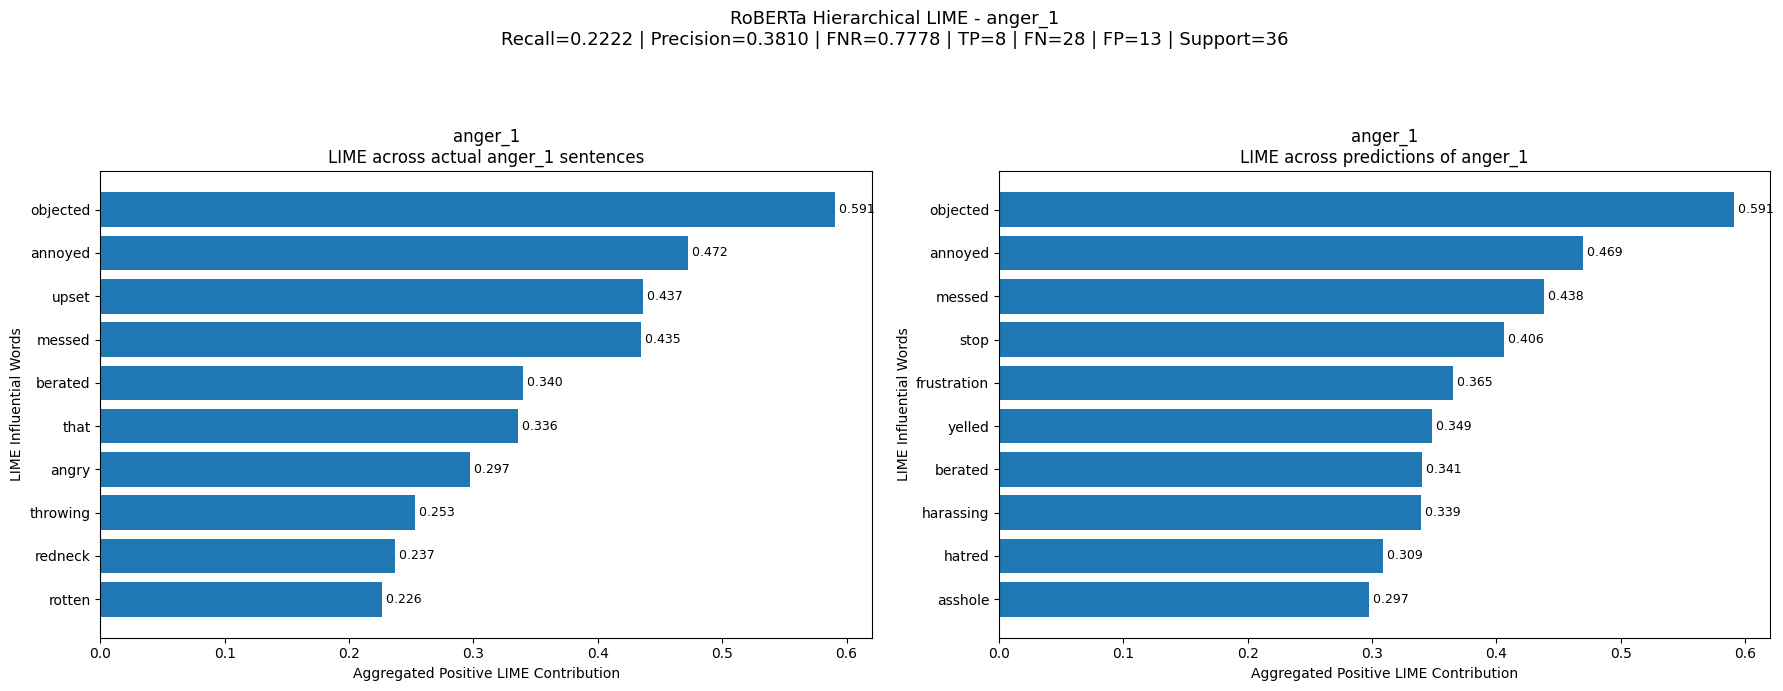

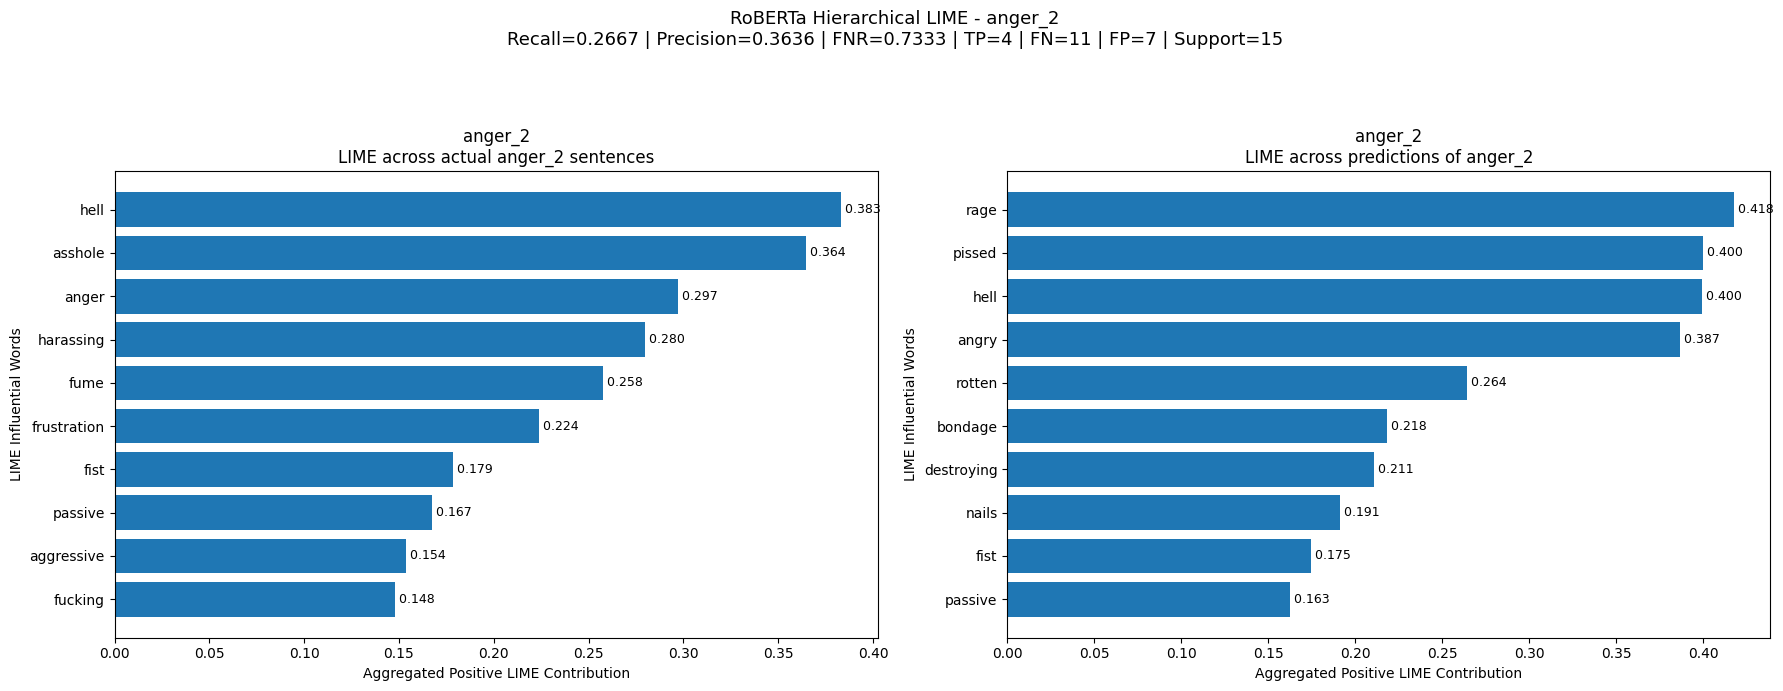

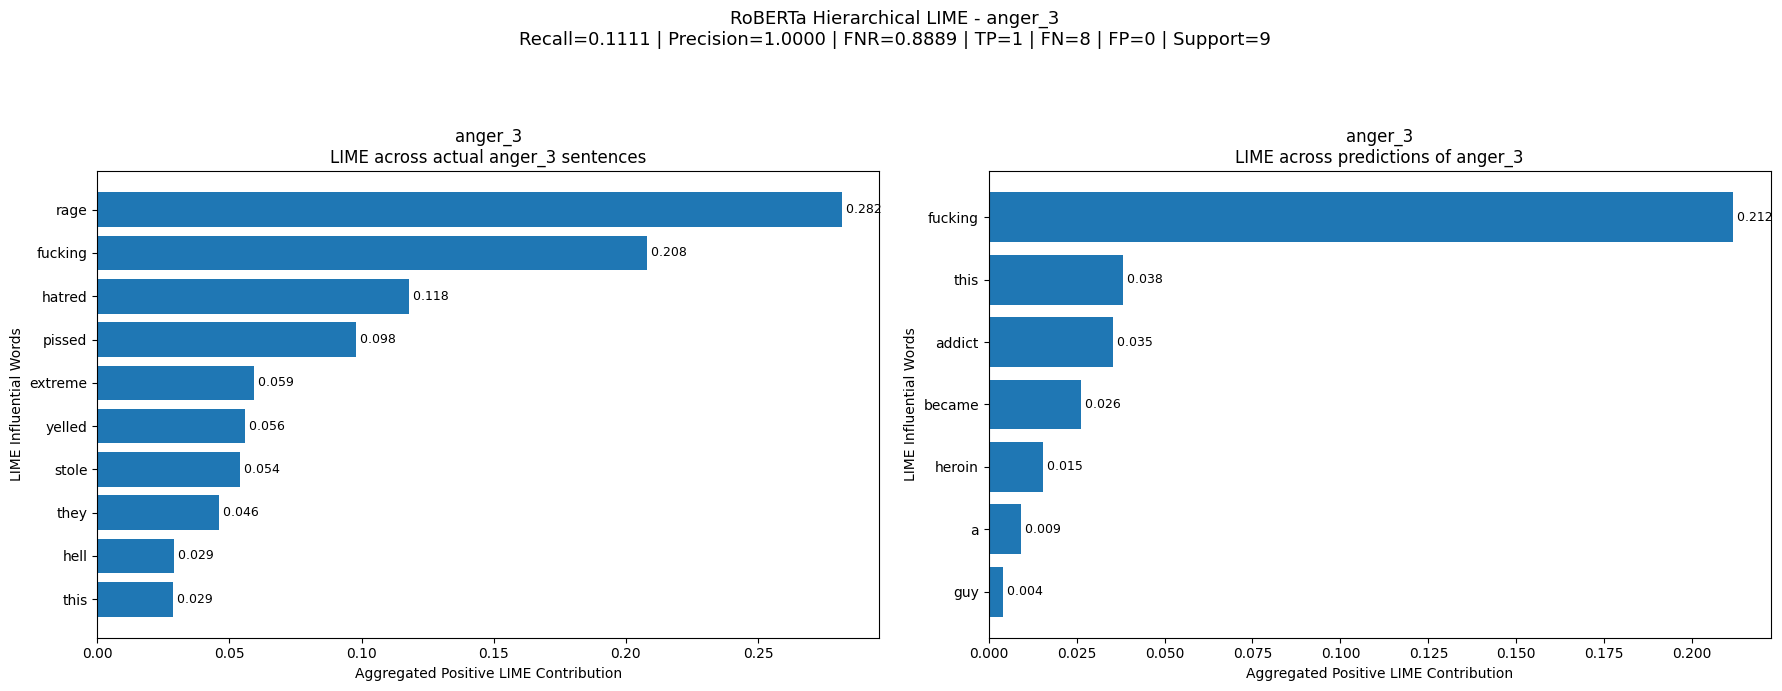

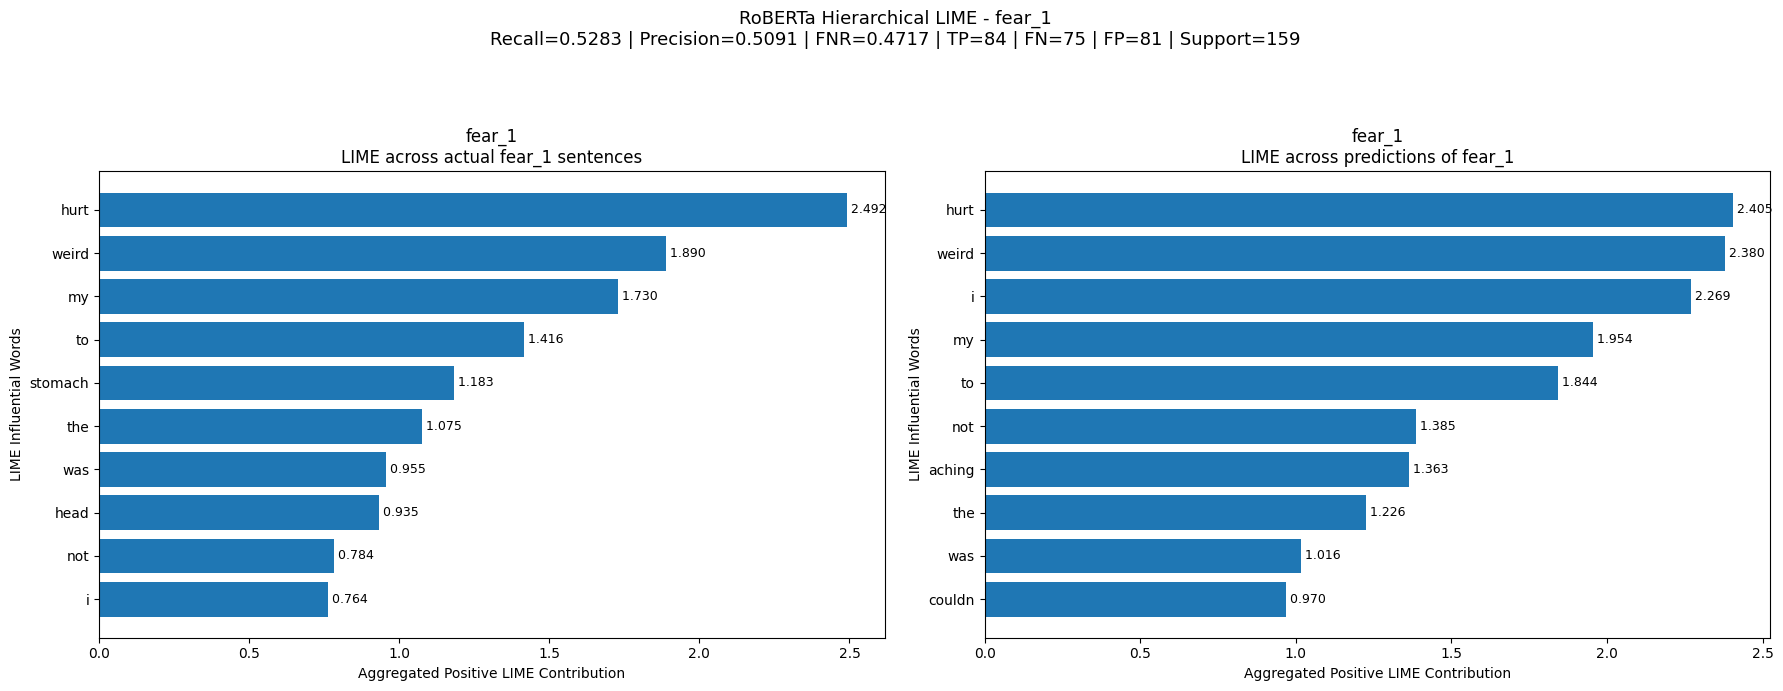

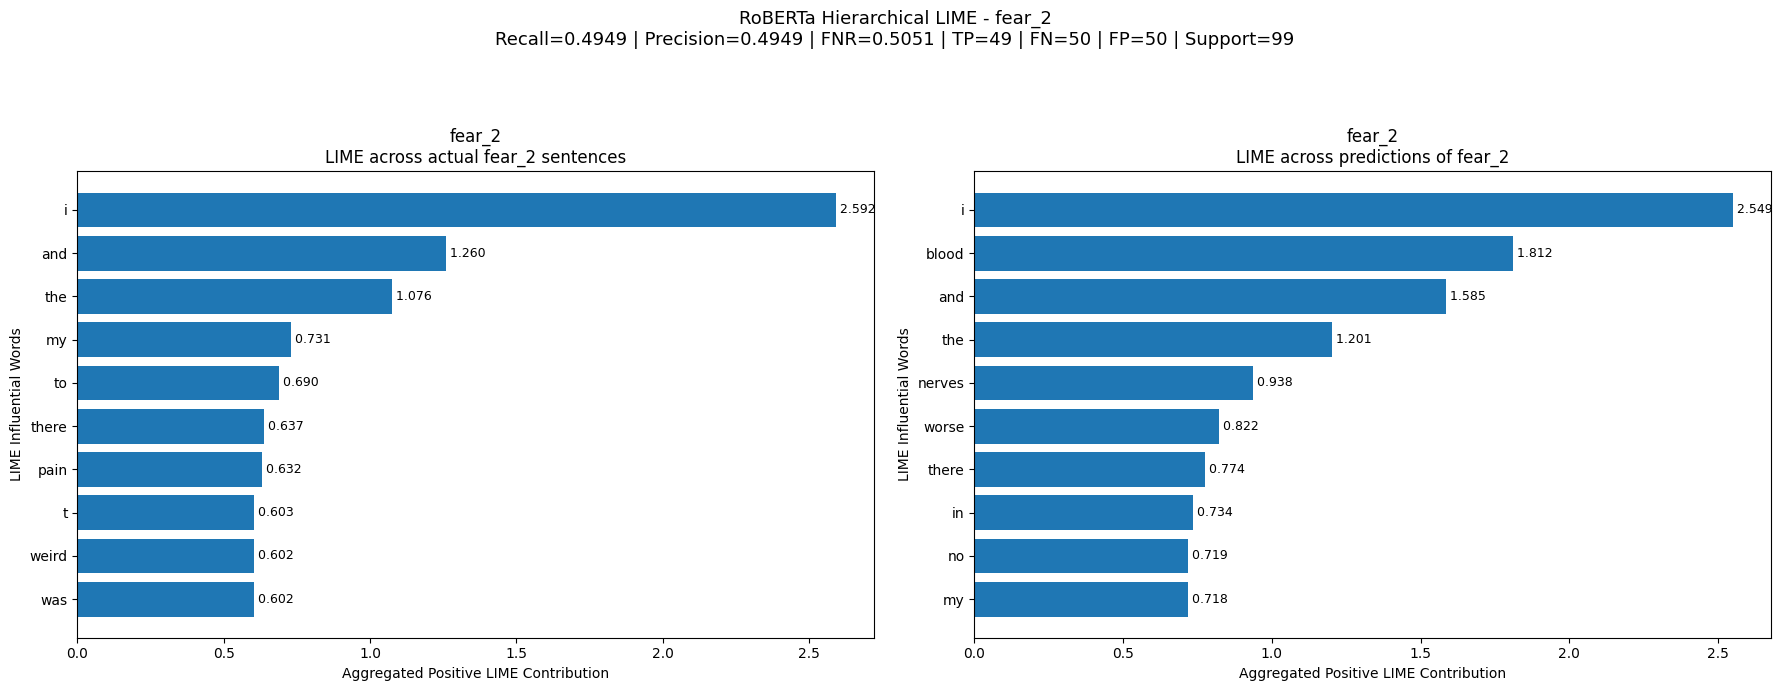

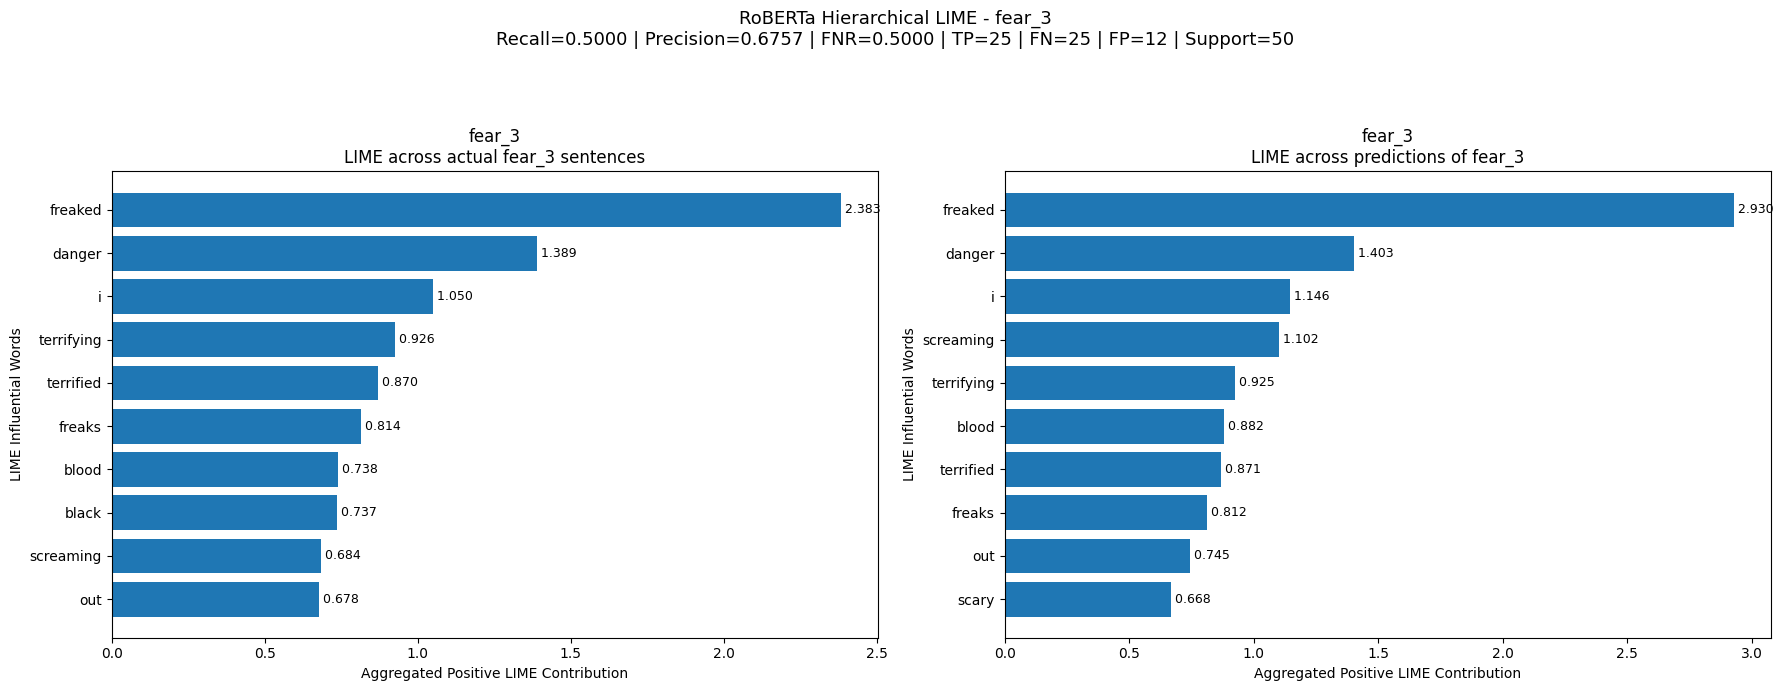

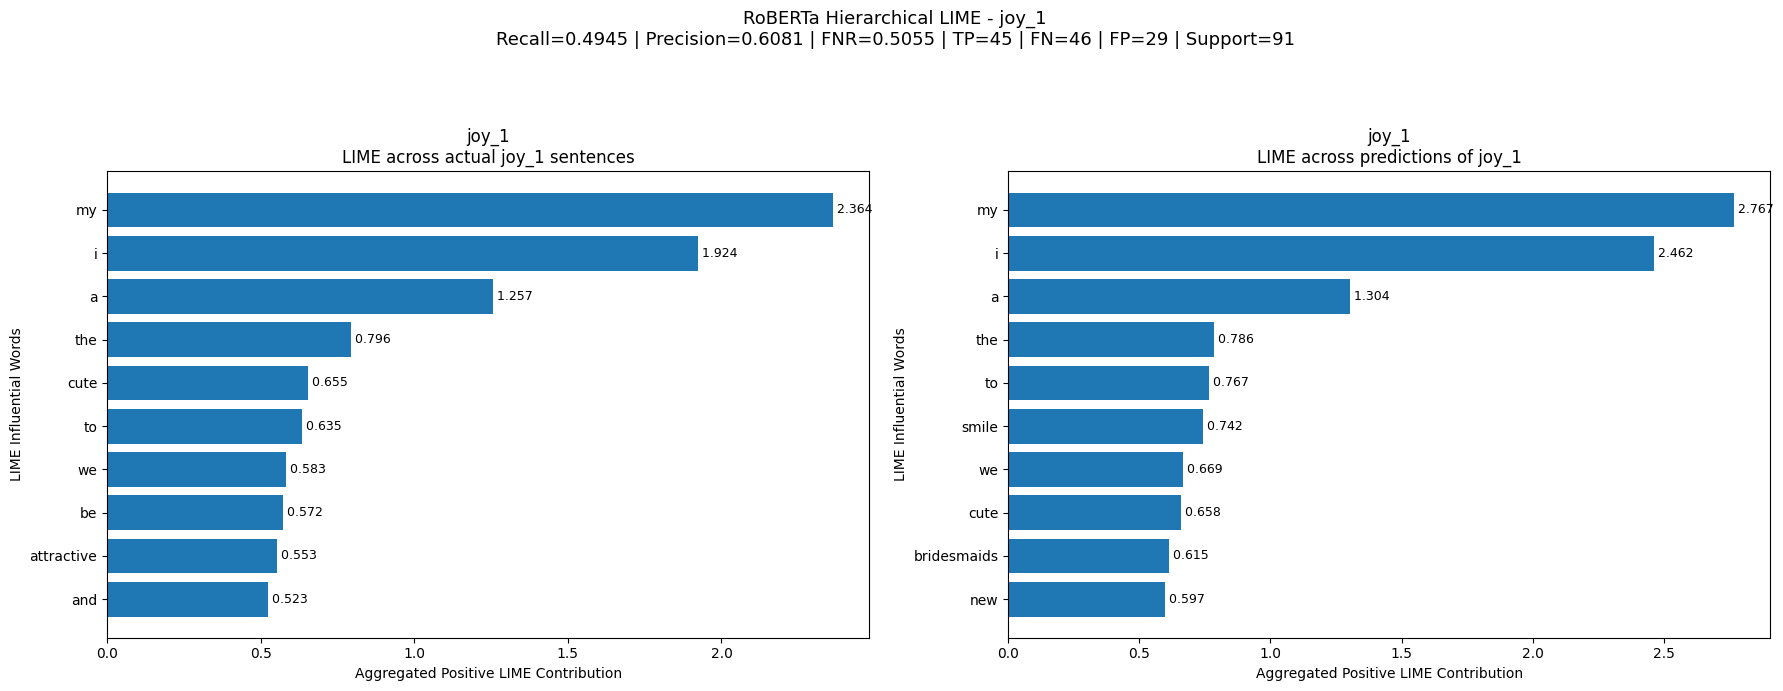

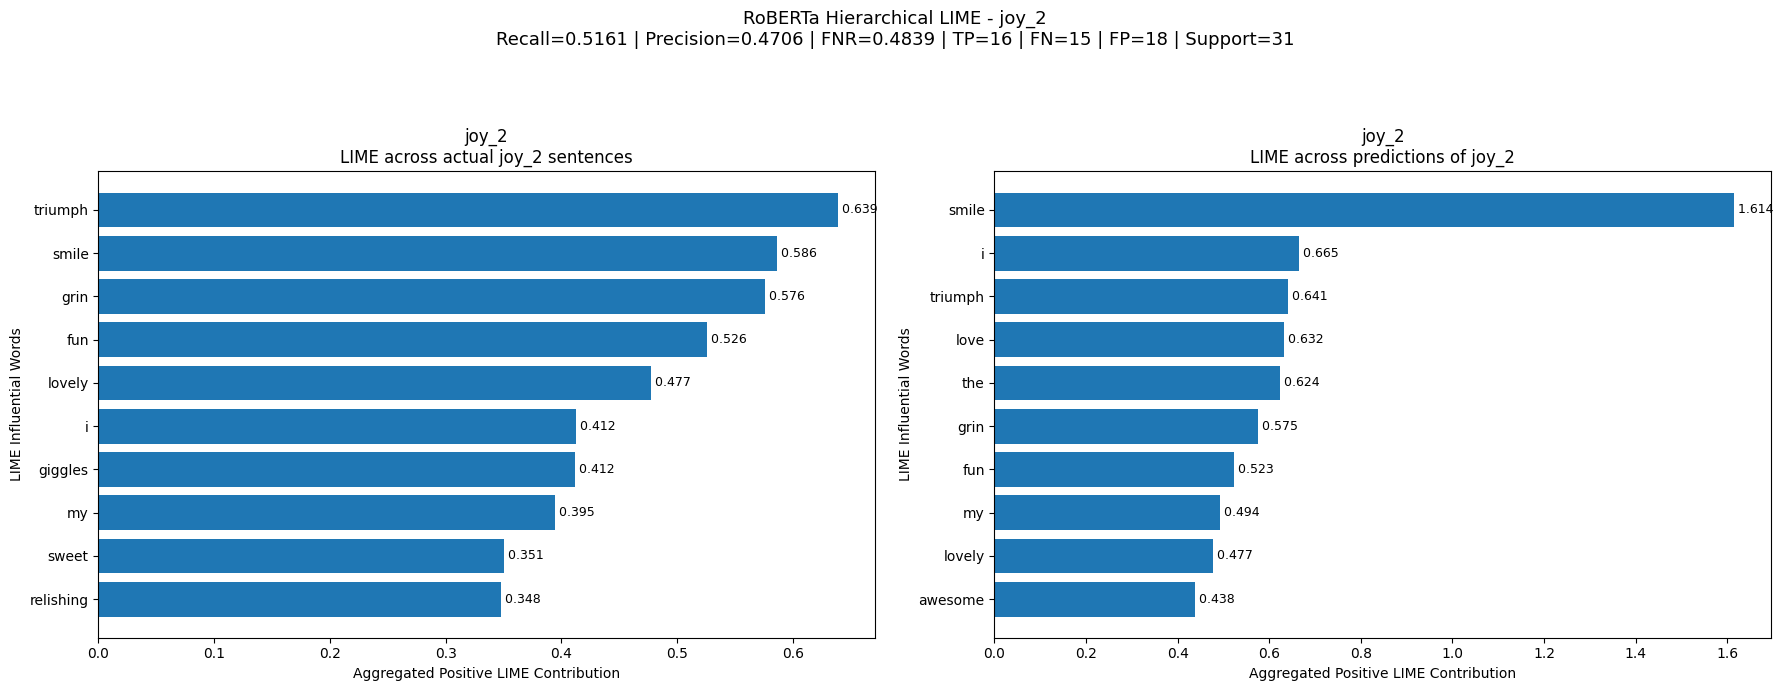

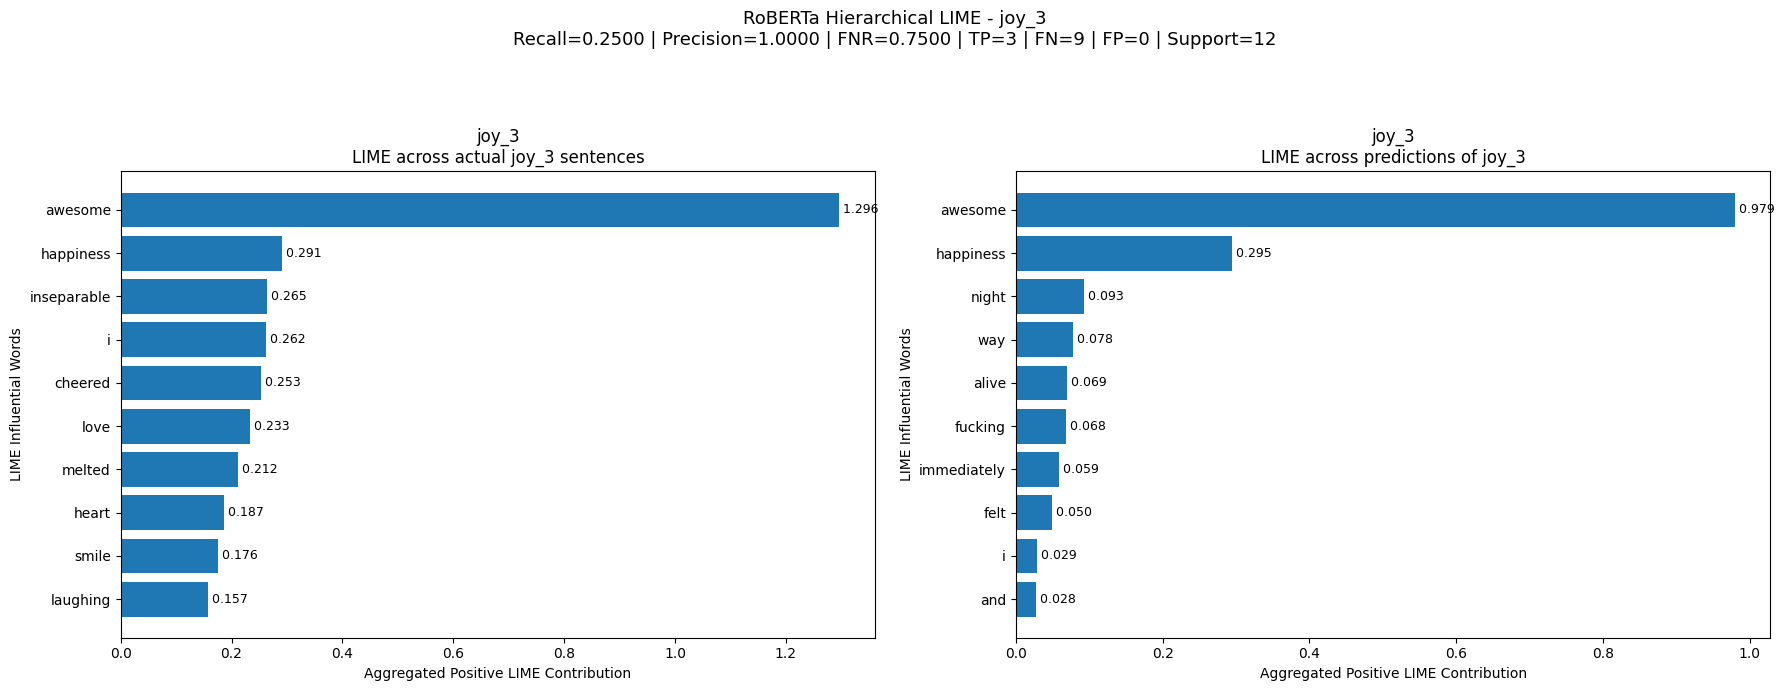

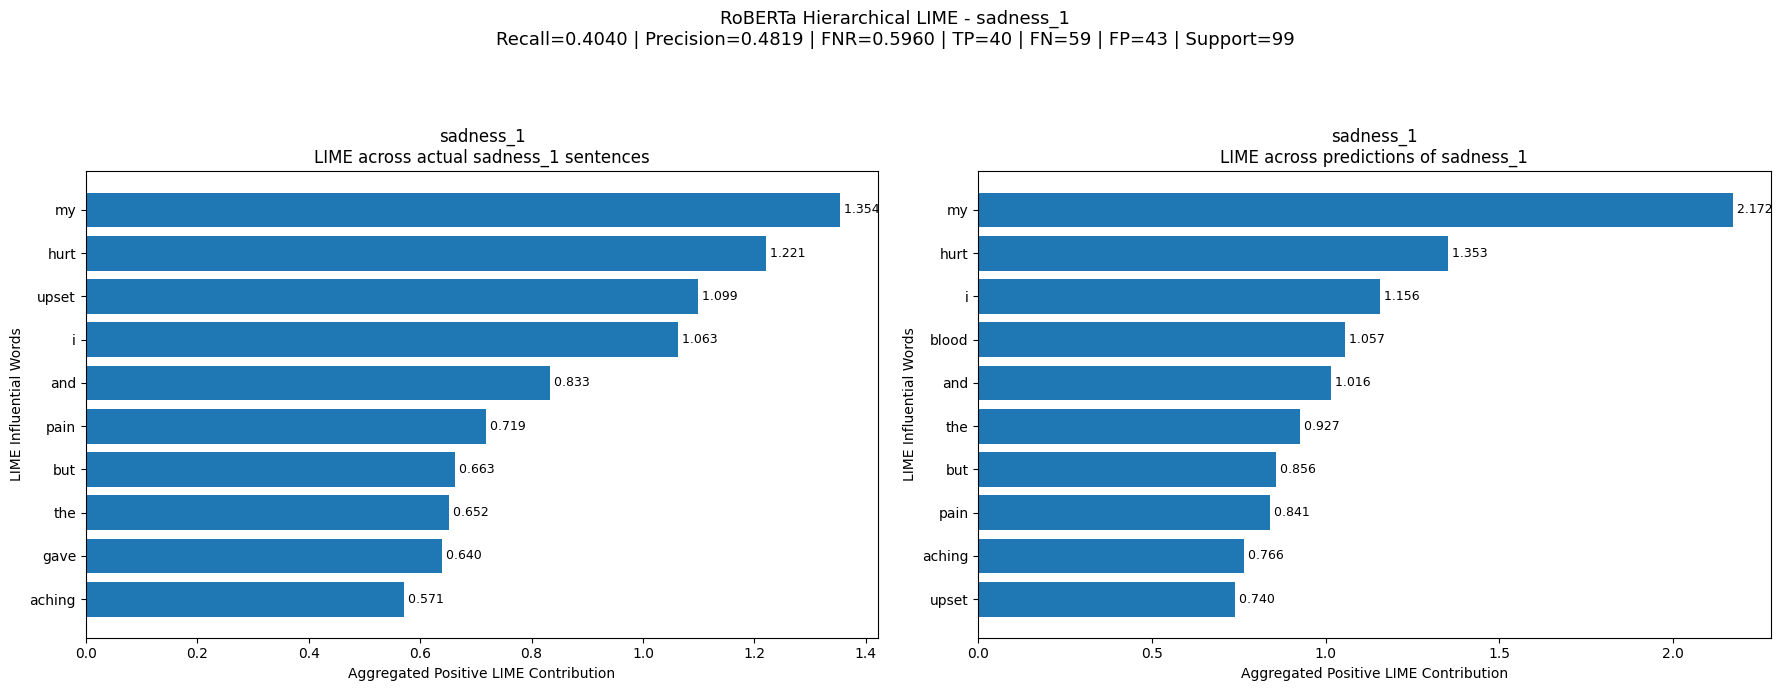

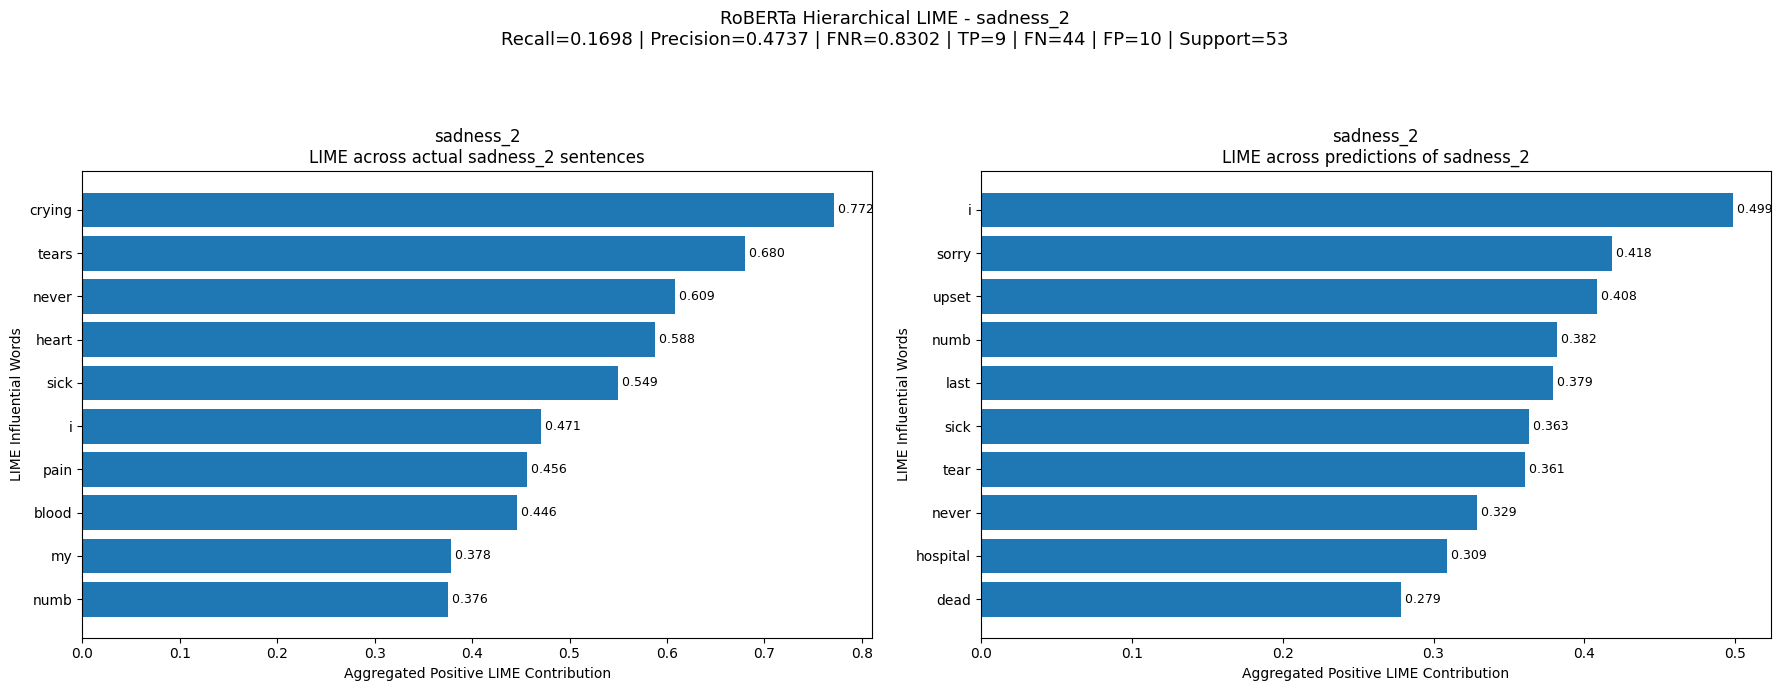

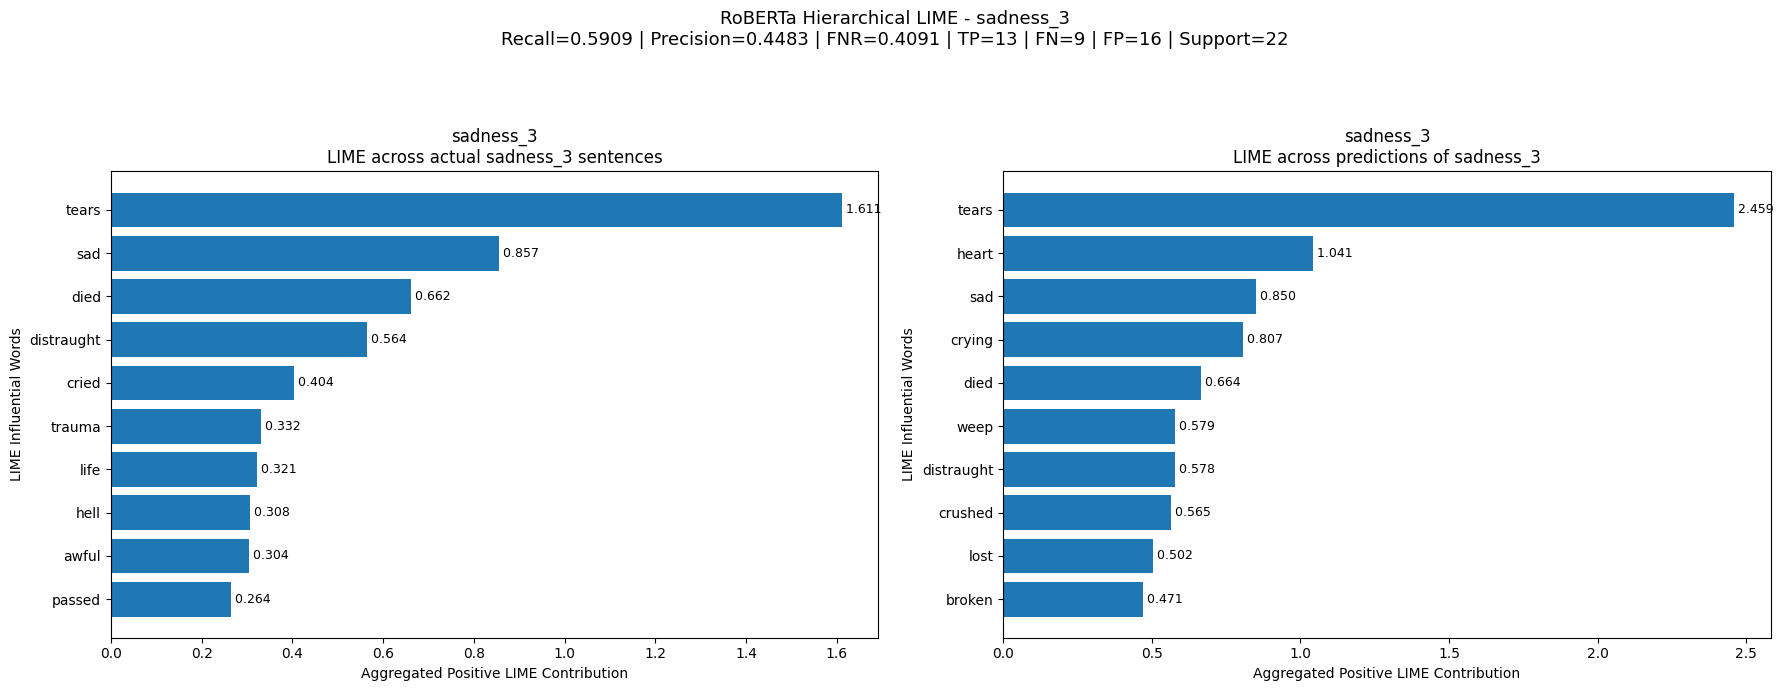

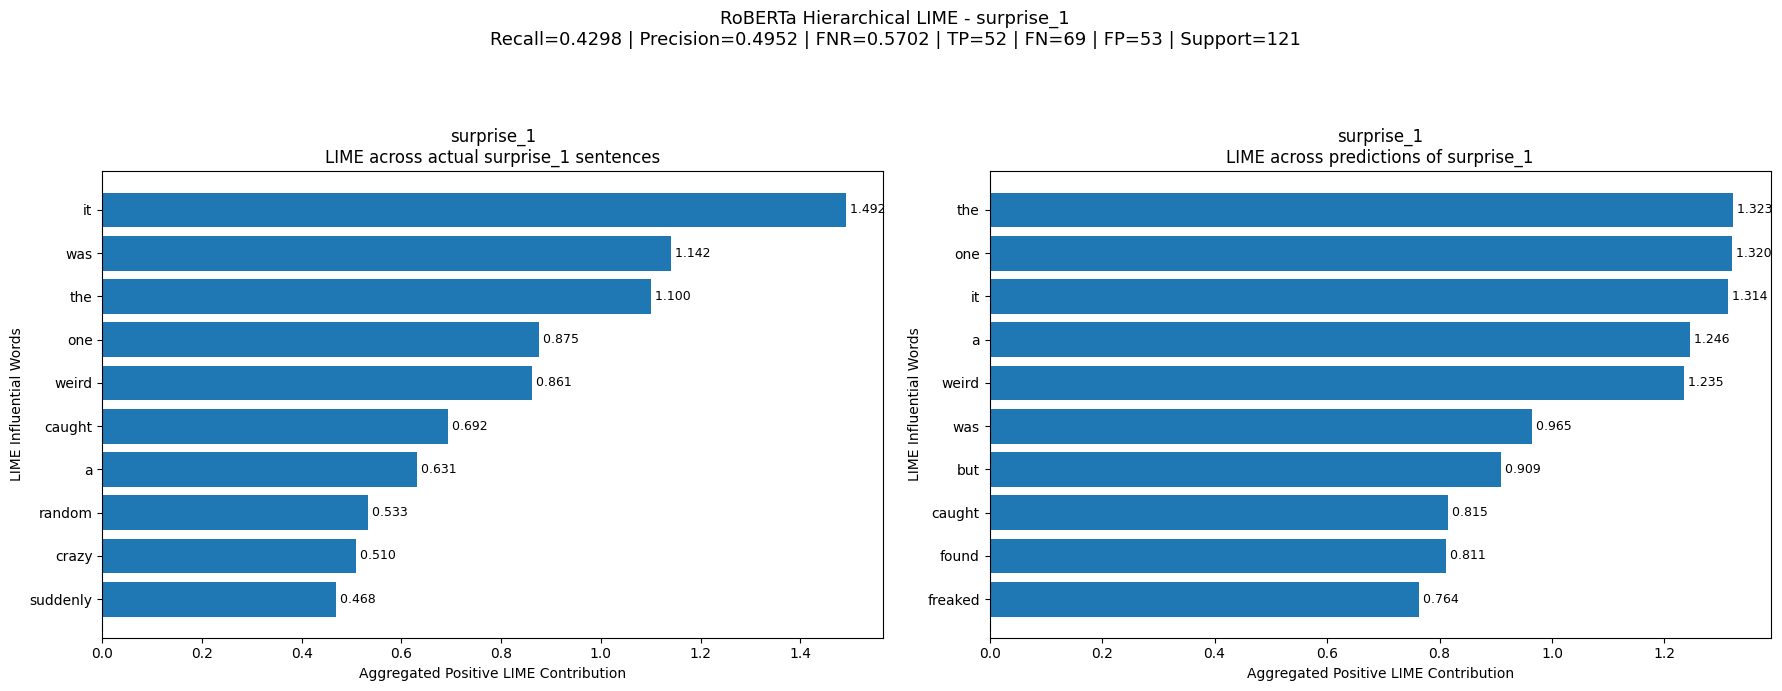

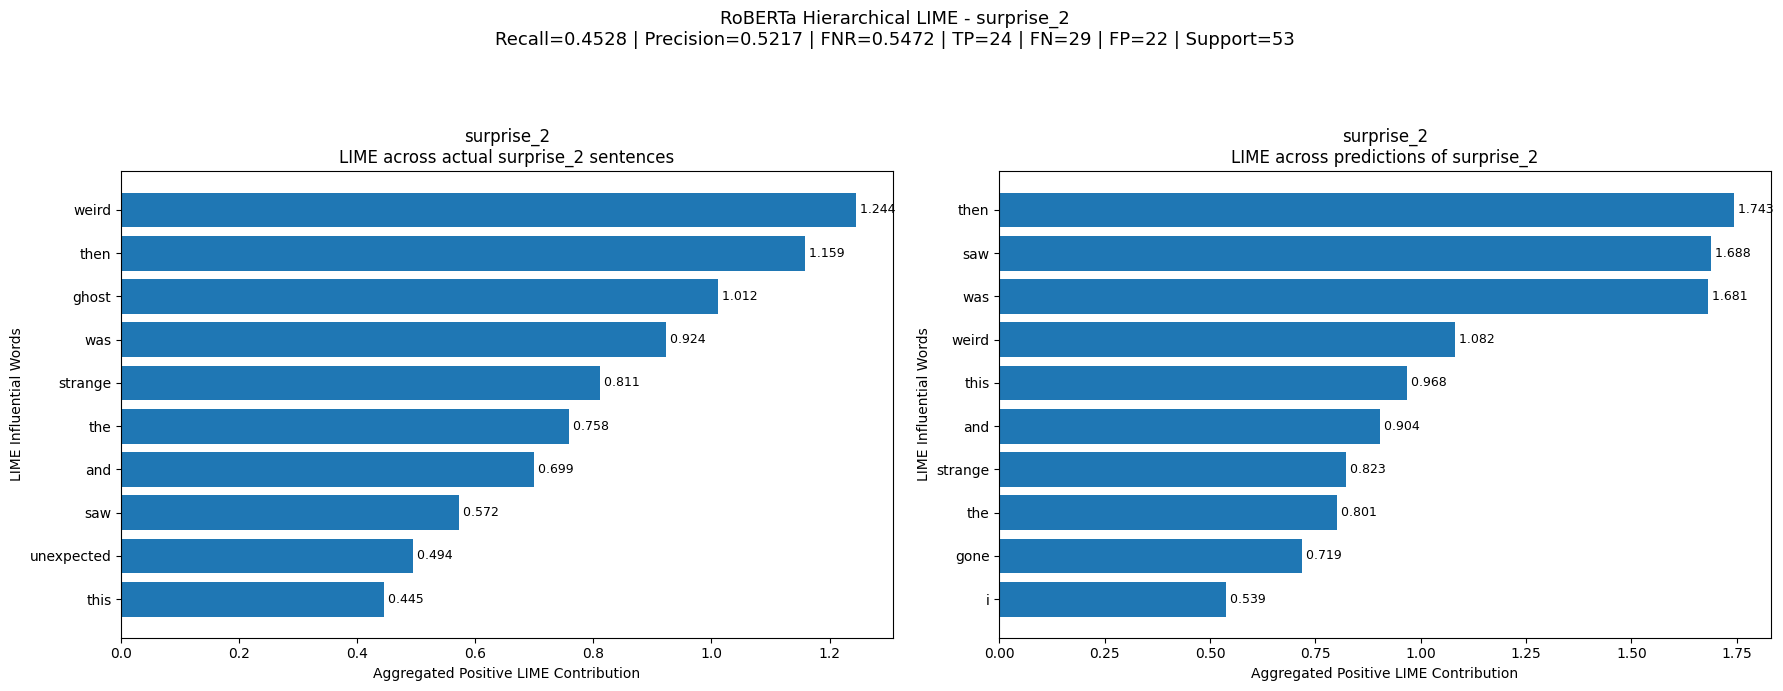

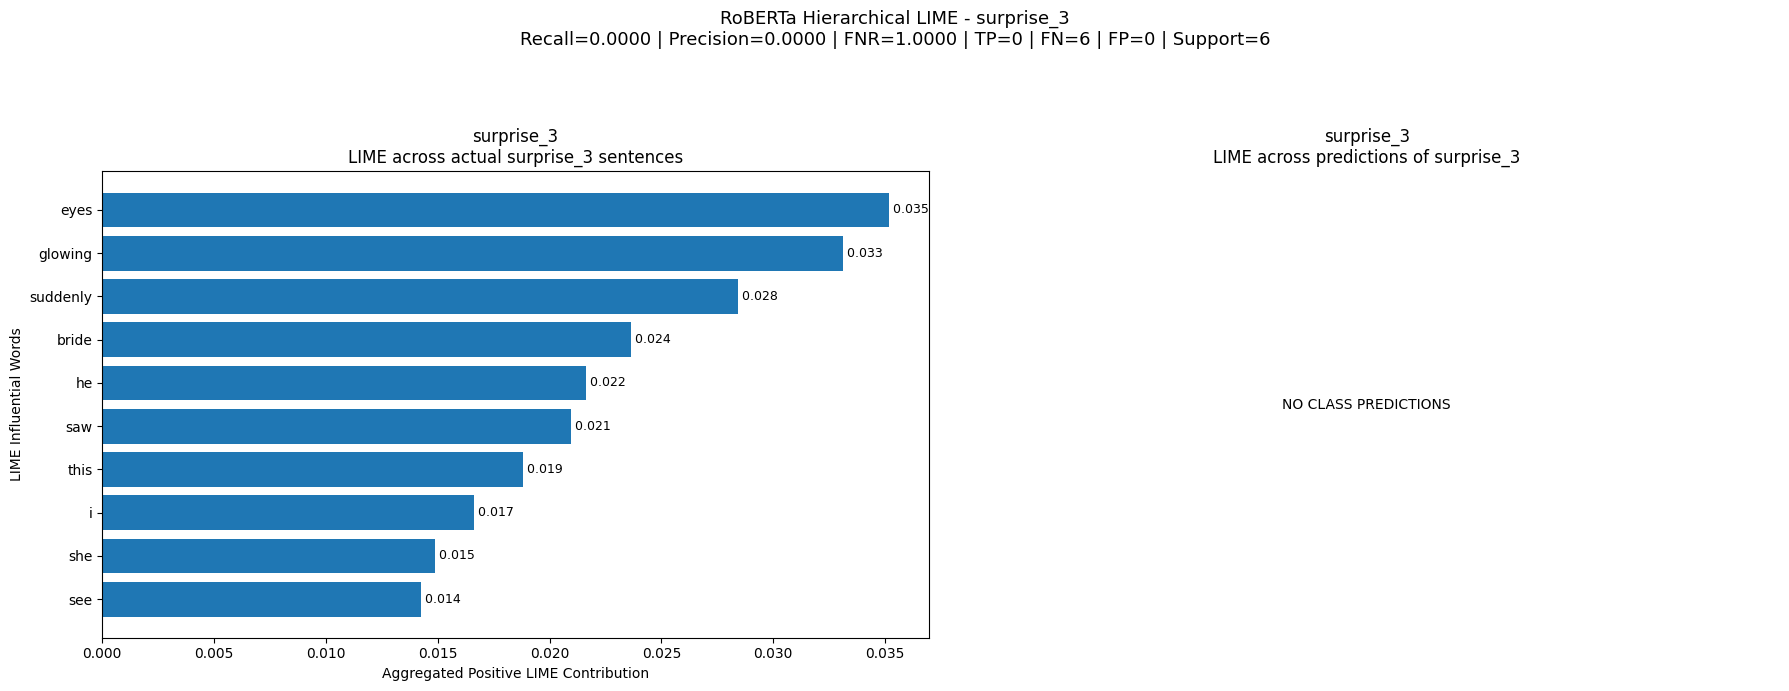


HIERARCHICAL LIME ANALYSIS COMPLETED

Only one LIME file created:
/content/drive/MyDrive/RoBERTa_Hierarchical_LIME_Results.csv

Columns:
class | recall | precision | fnr | TP | TN | FN | FP | support | true_class_lime_words | predicted_class_lime_words

All influential words come only from LIME.
The visualizations are displayed only and are not saved.


In [3]:
# =========================================================
# 28. HIERARCHICAL LIME ANALYSIS
# =========================================================
import sys,re,subprocess,importlib.util
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

if importlib.util.find_spec("lime") is None:
    subprocess.check_call([sys.executable,"-m","pip","install","lime","-q"])

from lime.lime_text import LimeTextExplainer

LIME_MAX_LENGTH=128
LIME_NUM_SAMPLES=1000
LIME_BATCH_SIZE=64
TOP_WORDS_VISUAL=10
HIERARCHICAL_LIME_FILE="/content/drive/MyDrive/RoBERTa_Hierarchical_LIME_Results.csv"

step1_lime_model=trainer_step1.model.to(device)
step2_lime_model=trainer_step2.model.to(device)
step1_lime_model.eval()
step2_lime_model.eval()

test_texts_hierarchical=test_split["text"].astype(str).tolist()

print("\n"+"="*90)
print("FINAL HIERARCHICAL PREDICTIONS")
print("="*90)

# =========================================================
# 29. FINAL STEP 1 PREDICTIONS
# =========================================================
pred_step1=trainer_step1.predict(test_step1_ds)
step1_logits=pred_step1.predictions
step1_probs=1/(1+np.exp(-step1_logits))
pred_emotions=(step1_probs>=0.5).astype(int)

# =========================================================
# 30. FINAL STEP 2 PREDICTIONS
# =========================================================
pred_step2=trainer_step2.predict(test_step2_ds)
step2_logits=pred_step2.predictions
true_intensities=pred_step2.label_ids.astype(int)

step2_probs=torch.softmax(
    torch.tensor(step2_logits),
    dim=-1
).numpy()

pred_intensities=np.argmax(step2_probs,axis=-1)
final_pred_intensities=pred_intensities*pred_emotions

# =========================================================
# 31. CREATE FINAL 15 HIERARCHICAL CLASSES
# =========================================================
true_binary_15=np.zeros(
    (true_intensities.shape[0],len(LABELS)),
    dtype=int
)

pred_binary_15=np.zeros(
    (true_intensities.shape[0],len(LABELS)),
    dtype=int
)

prob_binary_15=np.zeros(
    (true_intensities.shape[0],len(LABELS)),
    dtype=float
)

for emotion_index,emotion in enumerate(EMOTIONS):
    for level in LEVELS:
        class_index=emotion_index*3+(level-1)

        true_binary_15[:,class_index]=(
            true_intensities[:,emotion_index]==level
        ).astype(int)

        pred_binary_15[:,class_index]=(
            final_pred_intensities[:,emotion_index]==level
        ).astype(int)

        prob_binary_15[:,class_index]=(
            step1_probs[:,emotion_index]*
            step2_probs[:,emotion_index,level]
        )

final_hierarchical_report=classification_report(
    true_binary_15,
    pred_binary_15,
    target_names=LABELS,
    zero_division=0,
    output_dict=True
)

label2id={label:i for i,label in enumerate(LABELS)}

# =========================================================
# 32. HIERARCHICAL PREDICTION FUNCTION FOR LIME
# =========================================================
def hierarchical_lime_probabilities(texts):
    if isinstance(texts,str):
        texts=[texts]

    texts=list(texts)
    all_probs=[]

    for start in range(0,len(texts),LIME_BATCH_SIZE):
        batch=texts[start:start+LIME_BATCH_SIZE]

        inputs=tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=LIME_MAX_LENGTH,
            return_tensors="pt"
        )

        inputs={k:v.to(device) for k,v in inputs.items()}

        with torch.no_grad():
            step1_output=step1_lime_model(**inputs)
            probs1=torch.sigmoid(step1_output.logits)

            step2_output=step2_lime_model(**inputs)

            if isinstance(step2_output,dict):
                logits2=step2_output["logits"]
            else:
                logits2=step2_output.logits

            probs2=torch.softmax(logits2,dim=-1)

        combined=torch.zeros(
            (len(batch),len(LABELS)),
            device=device
        )

        for emotion_index,emotion in enumerate(EMOTIONS):
            for level in LEVELS:
                class_index=emotion_index*3+(level-1)

                combined[:,class_index]=(
                    probs1[:,emotion_index]*
                    probs2[:,emotion_index,level]
                )

        all_probs.append(
            combined.detach().cpu().numpy()
        )

    return np.vstack(all_probs)

# =========================================================
# 33. CLASS-SPECIFIC LIME PREDICTOR
# =========================================================
def create_hierarchical_lime_predictor(target_label):
    class_index=label2id[target_label]

    def predictor(texts):
        probs=hierarchical_lime_probabilities(texts)
        positive=probs[:,class_index]
        negative=1.0-positive
        return np.column_stack([negative,positive])

    return predictor

# =========================================================
# 34. NORMALIZE LIME WORD
# =========================================================
def normalize_lime_word(word):
    word=str(word).lower().strip()
    word=re.sub(r"[^a-z0-9'_]+","",word)
    return word if word else None

# =========================================================
# 35. AGGREGATE LIME WORDS
# =========================================================
# All influential words come ONLY from LIME.
# =========================================================
def aggregate_hierarchical_lime_words(indices,target_label,label_name):
    if len(indices)==0:
        return [],f"NO {label_name.upper()}"

    explainer=LimeTextExplainer(
        class_names=[f"NOT_{target_label}",target_label],
        split_expression=r"\W+",
        bow=True,
        random_state=SEED
    )

    predictor=create_hierarchical_lime_predictor(target_label)
    word_weights={}

    for count,test_index in enumerate(indices,start=1):
        sentence=str(test_texts_hierarchical[test_index])

        tokens=re.findall(r"\b[\w']+\b",sentence.lower())
        unique_tokens=list(dict.fromkeys(tokens))
        num_features=max(1,len(unique_tokens))

        try:
            explanation=explainer.explain_instance(
                text_instance=sentence,
                classifier_fn=predictor,
                labels=[1],
                num_features=num_features,
                num_samples=LIME_NUM_SAMPLES
            )

            lime_values=explanation.as_list(label=1)

            for word,weight in lime_values:
                if weight<=0:
                    continue

                word=normalize_lime_word(word)

                if word is None:
                    continue

                if word not in word_weights:
                    word_weights[word]=0.0

                word_weights[word]+=float(weight)

        except Exception as e:
            print(f"LIME error | {target_label} | index {test_index} | {e}")

        if count%20==0 or count==len(indices):
            print(f"{target_label} {label_name}: {count}/{len(indices)}")

    sorted_words=sorted(
        word_weights.items(),
        key=lambda x:x[1],
        reverse=True
    )

    word_string="; ".join(
        f"{word} ({weight:.4f})"
        for word,weight in sorted_words
    )

    return sorted_words,word_string

# =========================================================
# 36. TRUE-CLASS + PREDICTED-CLASS LIME
# =========================================================
lime_rows=[]
true_visualization_data={}
predicted_visualization_data={}

print("\n"+"="*90)
print("HIERARCHICAL AGGREGATED LIME ANALYSIS")
print("="*90)

for class_number,target_label in enumerate(LABELS,start=1):
    class_index=label2id[target_label]

    true_class=true_binary_15[:,class_index]
    predicted_class=pred_binary_15[:,class_index]

    tp=int(np.sum((true_class==1)&(predicted_class==1)))
    tn=int(np.sum((true_class==0)&(predicted_class==0)))
    fn=int(np.sum((true_class==1)&(predicted_class==0)))
    fp=int(np.sum((true_class==0)&(predicted_class==1)))

    support=int(np.sum(true_class==1))

    row=final_hierarchical_report.get(target_label,{})
    recall=float(row.get("recall",0.0))
    precision=float(row.get("precision",0.0))
    fnr=fn/(tp+fn) if (tp+fn)>0 else 0.0

    true_indices=np.where(true_class==1)[0]
    predicted_indices=np.where(predicted_class==1)[0]

    print("\n"+"-"*70)
    print(f"[{class_number}/{len(LABELS)}] {target_label}")
    print("True class sentences:",len(true_indices))
    print("Predicted class sentences:",len(predicted_indices))

    true_words,true_word_string=aggregate_hierarchical_lime_words(
        true_indices,
        target_label,
        "true class sentences"
    )

    predicted_words,predicted_word_string=aggregate_hierarchical_lime_words(
        predicted_indices,
        target_label,
        "class predictions"
    )

    true_visualization_data[target_label]=true_words
    predicted_visualization_data[target_label]=predicted_words

    lime_rows.append({
        "class":target_label,
        "recall":round(recall,4),
        "precision":round(precision,4),
        "fnr":round(fnr,4),
        "TP":tp,
        "TN":tn,
        "FN":fn,
        "FP":fp,
        "support":support,
        "true_class_lime_words":true_word_string,
        "predicted_class_lime_words":predicted_word_string
    })

# =========================================================
# 37. SAVE ONE HIERARCHICAL LIME CSV
# =========================================================
hierarchical_lime_df=pd.DataFrame(lime_rows)

hierarchical_lime_df=hierarchical_lime_df[
    [
        "class",
        "recall",
        "precision",
        "fnr",
        "TP",
        "TN",
        "FN",
        "FP",
        "support",
        "true_class_lime_words",
        "predicted_class_lime_words"
    ]
]

hierarchical_lime_df.to_csv(
    HIERARCHICAL_LIME_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("\n"+"="*100)
print("FINAL HIERARCHICAL LIME RESULTS")
print("="*100)

display(hierarchical_lime_df)

print("\nSaved:")
print(HIERARCHICAL_LIME_FILE)

# =========================================================
# 38. INLINE VISUALIZATIONS FOR ALL 15 CLASSES
# =========================================================
# LEFT  = LIME aggregated across true-class sentences
# RIGHT = LIME aggregated across actual model predictions
# Nothing is saved as PNG/PDF.
# =========================================================
for target_label in LABELS:
    true_words=true_visualization_data.get(target_label,[])[:TOP_WORDS_VISUAL]
    predicted_words=predicted_visualization_data.get(target_label,[])[:TOP_WORDS_VISUAL]

    fig,axes=plt.subplots(1,2,figsize=(18,7))

    if len(true_words)>0:
        names=[word for word,weight in true_words][::-1]
        values=[weight for word,weight in true_words][::-1]
        bars=axes[0].barh(names,values)

        for bar,value in zip(bars,values):
            axes[0].text(
                bar.get_width(),
                bar.get_y()+bar.get_height()/2,
                f" {value:.3f}",
                va="center",
                fontsize=9
            )

        axes[0].set_xlabel("Aggregated Positive LIME Contribution")
        axes[0].set_ylabel("LIME Influential Words")
    else:
        axes[0].text(
            0.5,0.5,
            "No true-class LIME words",
            ha="center",
            va="center"
        )
        axes[0].axis("off")

    axes[0].set_title(
        f"{target_label}\nLIME across actual {target_label} sentences"
    )

    if len(predicted_words)>0:
        names=[word for word,weight in predicted_words][::-1]
        values=[weight for word,weight in predicted_words][::-1]
        bars=axes[1].barh(names,values)

        for bar,value in zip(bars,values):
            axes[1].text(
                bar.get_width(),
                bar.get_y()+bar.get_height()/2,
                f" {value:.3f}",
                va="center",
                fontsize=9
            )

        axes[1].set_xlabel("Aggregated Positive LIME Contribution")
        axes[1].set_ylabel("LIME Influential Words")
    else:
        axes[1].text(
            0.5,0.5,
            "NO CLASS PREDICTIONS",
            ha="center",
            va="center"
        )
        axes[1].axis("off")

    axes[1].set_title(
        f"{target_label}\nLIME across predictions of {target_label}"
    )

    metrics=hierarchical_lime_df[
        hierarchical_lime_df["class"]==target_label
    ].iloc[0]

    fig.suptitle(
        f"RoBERTa Hierarchical LIME - {target_label}\n"
        f"Recall={metrics['recall']:.4f} | "
        f"Precision={metrics['precision']:.4f} | "
        f"FNR={metrics['fnr']:.4f} | "
        f"TP={metrics['TP']} | "
        f"FN={metrics['FN']} | "
        f"FP={metrics['FP']} | "
        f"Support={metrics['support']}",
        fontsize=13
    )

    plt.tight_layout(rect=[0,0,1,0.91])
    plt.show()
    plt.close(fig)

# =========================================================
# 39. FINISHED
# =========================================================
print("\n"+"="*100)
print("HIERARCHICAL LIME ANALYSIS COMPLETED")
print("="*100)

print("\nOnly one LIME file created:")
print(HIERARCHICAL_LIME_FILE)

print("\nColumns:")
print(
    "class | recall | precision | fnr | TP | TN | FN | FP | support | "
    "true_class_lime_words | predicted_class_lime_words"
)

print("\nAll influential words come only from LIME.")
print("The visualizations are displayed only and are not saved.")